# The money figure: noisy single-SQS vs. learned Boltzmann average

A single SQS draws one oxygen-vacancy arrangement at random and reports its
relaxed energy as "the" `G(v)`. But arrangements at the same `(composition, v)`
have genuinely different energies, so that one draw is noisy: **0.2-0.8 eV of
scatter**, worst exactly where it matters (high `v`, reducing conditions).

This notebook reproduces the harness in [`PLAN.md`](../PLAN.md) Section 7 end to
end: train the baseline on synthetic data, score it against a brute-force
reference with hundreds of labeled arrangements per `(composition, v)`, and plot
single-SQS scatter against the learned Boltzmann average as more arrangements are
folded into the sum.

Until the offline CHGNet factory export lands (PLAN.md step 7), both the training
set and the brute-force reference are synthetic (`vacancy_gnn.data.synthetic`),
generated from the same fixed descriptor -> energy response so the comparison is
apples to apples. The convergence behavior shown here is the real point; the
residual gap to brute-force truth reflects this baseline's current fit quality
and is expected to shrink once real labels replace the synthetic placeholder.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from vacancy_gnn.data.featurize import build_graph
from vacancy_gnn.data.synthetic import (
    make_brute_force_reference,
    make_synthetic_dataset,
)
from vacancy_gnn.evaluate import evaluate, group_by_composition_and_v
from vacancy_gnn.metrics import free_energy_convergence
from vacancy_gnn.models.baseline import LinearBaseline
from vacancy_gnn.physics.boltzmann import free_energy
from vacancy_gnn.physics.constants import T_FR
from vacancy_gnn.train import train

RNG_SEED = 0

## Train the baseline on synthetic data

In [2]:
dataset = make_synthetic_dataset(
    n_compositions=40, arrangements_per_composition=12, seed=RNG_SEED
)
model = LinearBaseline(regularization=1e-2)
train_result = train(model, dataset, seed=RNG_SEED)
print(
    f"held-out validation: MAE={train_result.val_mae:.3f} eV, "
    f"RMSE={train_result.val_rmse:.3f} eV "
    f"(train={train_result.n_train}, val={train_result.n_val})"
)

held-out validation: MAE=0.380 eV, RMSE=0.471 eV (train=336, val=72)


## Score against the brute-force reference

The reference has 200 labeled arrangements at a fixed `(composition, v)`, on a
composition the model never saw during training (composition-held-out, per
PLAN.md Section 8 honesty checks).

In [3]:
reference = make_brute_force_reference(
    n_compositions=1, vacancy_levels=(2,), arrangements_per_level=200, seed=1000
)
group = group_by_composition_and_v(reference)[0]
arrangements = [reference.arrangements[i] for i in group.indices]

true_energies = np.array([a.energy_ev for a in arrangements])
graphs = [build_graph(a, cutoff=5.0) for a in arrangements]
pred_energies = model.predict(graphs)

truth = free_energy(true_energies, T_FR)
print(f"{group.composition}, v={group.v}: brute-force truth G(v) = {truth:.4f} eV")

FeMnAl-ref-000, v=2: brute-force truth G(v) = -4.4566 eV


## The figure

- Red points: `G(v)` from single independent SQS draws (one arrangement each) —
  the status quo, and the noise this project exists to fix.
- Blue line: the learned Boltzmann average over the model's predicted energies,
  as more candidate arrangements are folded into the sum. The band is +/- 1
  standard deviation over the random order arrangements are added in.
- Dashed line: the brute-force truth from all 200 reference labels.

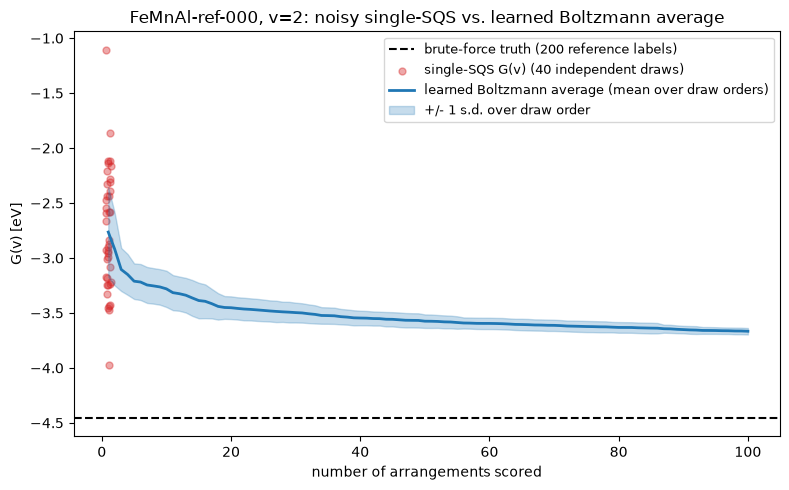

single-SQS draw std: 0.5459 eV
learned average std at n=100: 0.0294 eV


In [4]:
rng = np.random.default_rng(42)
n_draws = 40
single_sqs_draws = rng.choice(true_energies, size=n_draws, replace=True)
single_sqs_g = np.array([free_energy([e], T_FR) for e in single_sqs_draws])

n_seeds = 20
max_n_shown = 100
sample_sizes = np.arange(1, max_n_shown + 1)
model_curves = np.stack(
    [
        free_energy_convergence(pred_energies, T_FR, seed=s, sample_sizes=sample_sizes)[
            1
        ]
        for s in range(n_seeds)
    ]
)
model_mean = model_curves.mean(axis=0)
model_std = model_curves.std(axis=0)

fig, ax = plt.subplots(figsize=(8, 5))
ax.axhline(
    truth,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="brute-force truth (200 reference labels)",
    zorder=5,
)
jitter = rng.uniform(-0.4, 0.4, size=n_draws)
ax.scatter(
    1 + jitter,
    single_sqs_g,
    color="tab:red",
    alpha=0.4,
    s=25,
    label=f"single-SQS G(v) ({n_draws} independent draws)",
)
ax.plot(
    sample_sizes,
    model_mean,
    color="tab:blue",
    linewidth=2,
    label="learned Boltzmann average (mean over draw orders)",
)
ax.fill_between(
    sample_sizes,
    model_mean - model_std,
    model_mean + model_std,
    color="tab:blue",
    alpha=0.25,
    label="+/- 1 s.d. over draw order",
)
ax.set_xlabel("number of arrangements scored")
ax.set_ylabel("G(v) [eV]")
title = f"{group.composition}, v={group.v}: "
title += "noisy single-SQS vs. learned Boltzmann average"
ax.set_title(title)
ax.legend(loc="best", fontsize=9)
fig.tight_layout()
fig.savefig("money_figure.png", dpi=150)
plt.show()

print(f"single-SQS draw std: {single_sqs_g.std():.4f} eV")
print(f"learned average std at n={max_n_shown}: {model_std[-1]:.4f} eV")

## Why the average, not the lowest arrangement (PLAN.md Section 2.1)

The `T -> 0` limit of the Boltzmann sum is exactly the lowest-energy arrangement.
The full evaluation harness reports, per composition, how far that limit departs
from the reactor-temperature average -- the "min-vs-average divergence" that
flags entropy-dominated compositions where taking the minimum would misrank the
result.

In [5]:
report = evaluate(model, reference, reactor_temperature=T_FR)

print(f"parity: MAE={report.parity.mae:.4f} eV  RMSE={report.parity.rmse:.4f} eV\n")
for est in report.free_energy_accuracy:
    print(
        f"{est.composition} v={est.v}: truth={est.truth:.4f} eV  "
        f"model={est.model_estimate:.4f} eV  error={est.error:+.4f} eV"
    )
print()
for div in report.min_vs_average:
    label = "entropy-dominated" if div.entropy_dominated else "min-dominated"
    print(
        f"{div.composition} v={div.v}: G(T->0)={div.g_zero_t:.4f} eV  "
        f"G(T_reactor)={div.g_reactor_t:.4f} eV  ({label})"
    )

parity: MAE=0.3796 eV  RMSE=0.4722 eV

FeMnAl-ref-000 v=2: truth=-4.4566 eV  model=-3.7567 eV  error=+0.6999 eV

FeMnAl-ref-000 v=2: G(T->0)=-4.3742 eV  G(T_reactor)=-4.4566 eV  (entropy-dominated)
